In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, Circle



In [2]:
plt.rcParams.update({
'font.family': 'DejaVu Sans',
'font.size': 11,
'axes.titlesize': 13,
'axes.labelsize': 11,
'figure.dpi': 150,
'axes.spines.top': False,
'axes.spines.right': False,
})

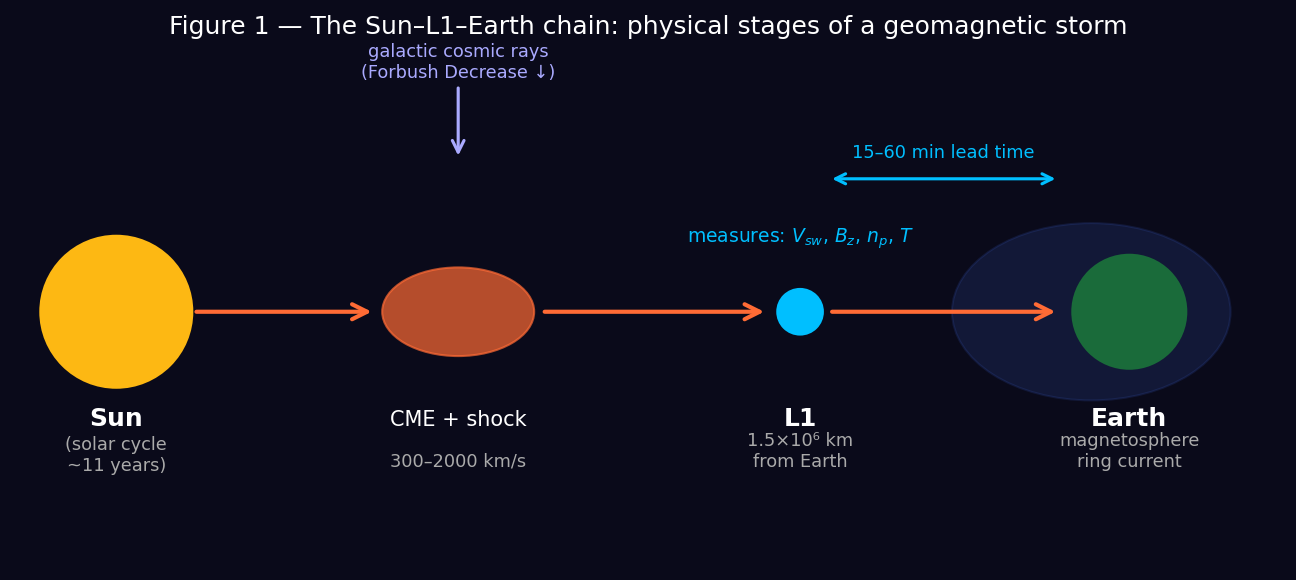

In [3]:
# ── Figure 1: Sun → L1 → Earth chain ──────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 2.5)
ax.axis('off')
ax.set_facecolor('#0a0a1a')
fig1.patch.set_facecolor('#0a0a1a')

sun = Circle((0.8, 0.5), 0.6, color='#FDB813', zorder=5)
ax.add_patch(sun)
ax.text(0.8, -0.4,  'Sun',                  color='white',   ha='center', fontsize=12, fontweight='bold')
ax.text(0.8, -0.75, '(solar cycle\n~11 years)', color='#aaaaaa', ha='center', fontsize=8.5)

cme = Ellipse((3.5, 0.5), 1.2, 0.7, color='#FF6B35', alpha=0.7, zorder=4)
ax.add_patch(cme)
ax.text(3.5, -0.4,  'CME + shock',    color='white',   ha='center', fontsize=10)
ax.text(3.5, -0.72, '300–2000 km/s', color='#aaaaaa', ha='center', fontsize=8.5)

l1 = Circle((6.2, 0.5), 0.18, color='#00BFFF', zorder=5)
ax.add_patch(l1)
ax.text(6.2, -0.4,  'L1',                          color='white',   ha='center', fontsize=12, fontweight='bold')
ax.text(6.2, -0.72, '1.5×10⁶ km\nfrom Earth',     color='#aaaaaa', ha='center', fontsize=8.5)
ax.text(6.2,  1.05, 'measures: $V_{sw}$, $B_z$, $n_p$, $T$', color='#00BFFF', ha='center', fontsize=9)

earth = Circle((8.8, 0.5), 0.45, color='#1a6b3a', zorder=5)
ax.add_patch(earth)
mag = Ellipse((8.5, 0.5), 2.2, 1.4, color='#4169E1', alpha=0.15, zorder=3)
ax.add_patch(mag)
ax.text(8.8, -0.4,  'Earth',                  color='white',   ha='center', fontsize=12, fontweight='bold')
ax.text(8.8, -0.72, 'magnetosphere\nring current', color='#aaaaaa', ha='center', fontsize=8.5)

for xy_start, xy_end in [((1.4, 0.5), (2.85, 0.5)), ((4.15, 0.5), (5.95, 0.5)), ((6.42, 0.5), (8.25, 0.5))]:
    ax.annotate('', xy=xy_end, xytext=xy_start,
                arrowprops=dict(arrowstyle='->', color='#FF6B35', lw=2, mutation_scale=18))

ax.annotate('', xy=(3.5, 1.7), xytext=(3.5, 2.3),
            arrowprops=dict(arrowstyle='->', color='#aaaaff', lw=1.5, mutation_scale=14))
ax.text(3.5, 2.35, 'galactic cosmic rays\n(Forbush Decrease ↓)',
        color='#aaaaff', ha='center', fontsize=8.5)

ax.annotate('', xy=(8.25, 1.55), xytext=(6.42, 1.55),
            arrowprops=dict(arrowstyle='<->', color='#00BFFF', lw=1.5, mutation_scale=12))
ax.text(7.33, 1.72, '15–60 min lead time', color='#00BFFF', ha='center', fontsize=8.5)

ax.set_title('Figure 1 — The Sun–L1–Earth chain: physical stages of a geomagnetic storm',
             color='white', pad=12, fontsize=12)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('images/fig1_chain.png', dpi=150, bbox_inches='tight')
plt.show()

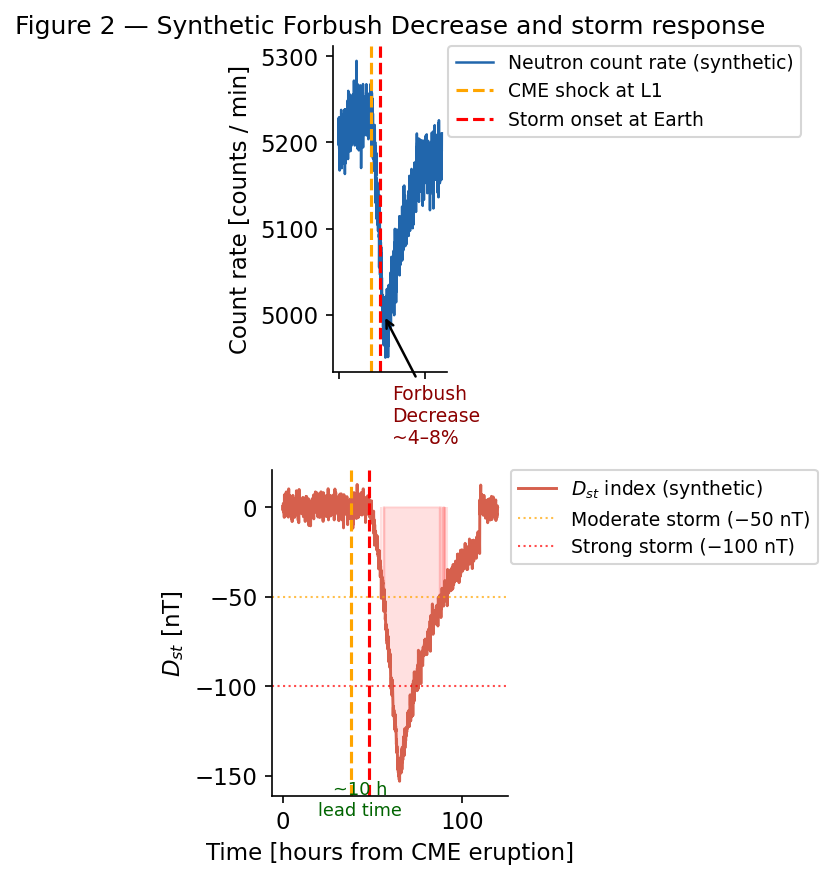

In [4]:
# ── Figure 2: Forbush Decrease + Dst synthetic profile ────────────────────────
np.random.seed(42)
t = np.linspace(0, 120, 1200)
baseline  = 5200 + 30 * np.sin(2 * np.pi * t / 130)
fd_profile = np.zeros(len(t))
fd_profile[(t >= 38) & (t < 52)] = -220 * ((t[(t >= 38) & (t < 52)] - 38) / 14) ** 1.3
fd_profile[(t >= 52) & (t < 58)] = -220
fd_profile[(t >= 58) & (t < 90)] = -220 * np.exp(-0.055 * (t[(t >= 58) & (t < 90)] - 58))
counts = baseline + fd_profile + np.random.normal(0, 18, len(t))

dst_base = np.zeros(len(t))
dst_base[(t >= 48) & (t < 65)] = -150 * ((t[(t >= 48) & (t < 65)] - 48) / 17) ** 1.5
dst_base[(t >= 65) & (t < 110)] = -150 * np.exp(-0.045 * (t[(t >= 65) & (t < 110)] - 65))
dst = dst_base + np.random.normal(0, 4, len(t))

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(t, counts, color='#2166ac', lw=1.2, label='Neutron count rate (synthetic)')
ax1.axvline(38, color='orange', lw=1.5, ls='--', label='CME shock at L1')
ax1.axvline(48, color='red',    lw=1.5, ls='--', label='Storm onset at Earth')
ax1.set_ylabel('Count rate [counts / min]')
ax1.set_title('Figure 2 — Synthetic Forbush Decrease and storm response', fontsize=12)
ax1.legend(fontsize=9, loc='lower right')
ax1.annotate('Forbush\nDecrease\n~4–8%', xy=(52, baseline.mean() - 200),
             xytext=(62, baseline.mean() - 350),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2), fontsize=9, color='darkred')

ax2.plot(t, dst, color='#d6604d', lw=1.4, label='$D_{st}$ index (synthetic)')
ax2.axhline(-50,  color='orange', lw=1, ls=':', alpha=0.7, label='Moderate storm (−50 nT)')
ax2.axhline(-100, color='red',    lw=1, ls=':', alpha=0.7, label='Strong storm (−100 nT)')
ax2.axvline(38, color='orange', lw=1.5, ls='--')
ax2.axvline(48, color='red',    lw=1.5, ls='--')
ax2.fill_between(t, dst, 0, where=(dst < -50), alpha=0.12, color='red')
ax2.set_ylabel('$D_{st}$ [nT]')
ax2.set_xlabel('Time [hours from CME eruption]')
ax2.legend(fontsize=9, loc='lower right')
ax2.annotate('', xy=(48, -165), xytext=(38, -165),
             arrowprops=dict(arrowstyle='<->', color='green', lw=1.5, mutation_scale=12))
ax2.text(43, -172, '~10 h\nlead time', ha='center', fontsize=8.5, color='darkgreen')

for ax in [ax1, ax2]:
    ax.set_aspect('equal')
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig('images/fig2_forbush_dst.png', dpi=150, bbox_inches='tight')
plt.show()

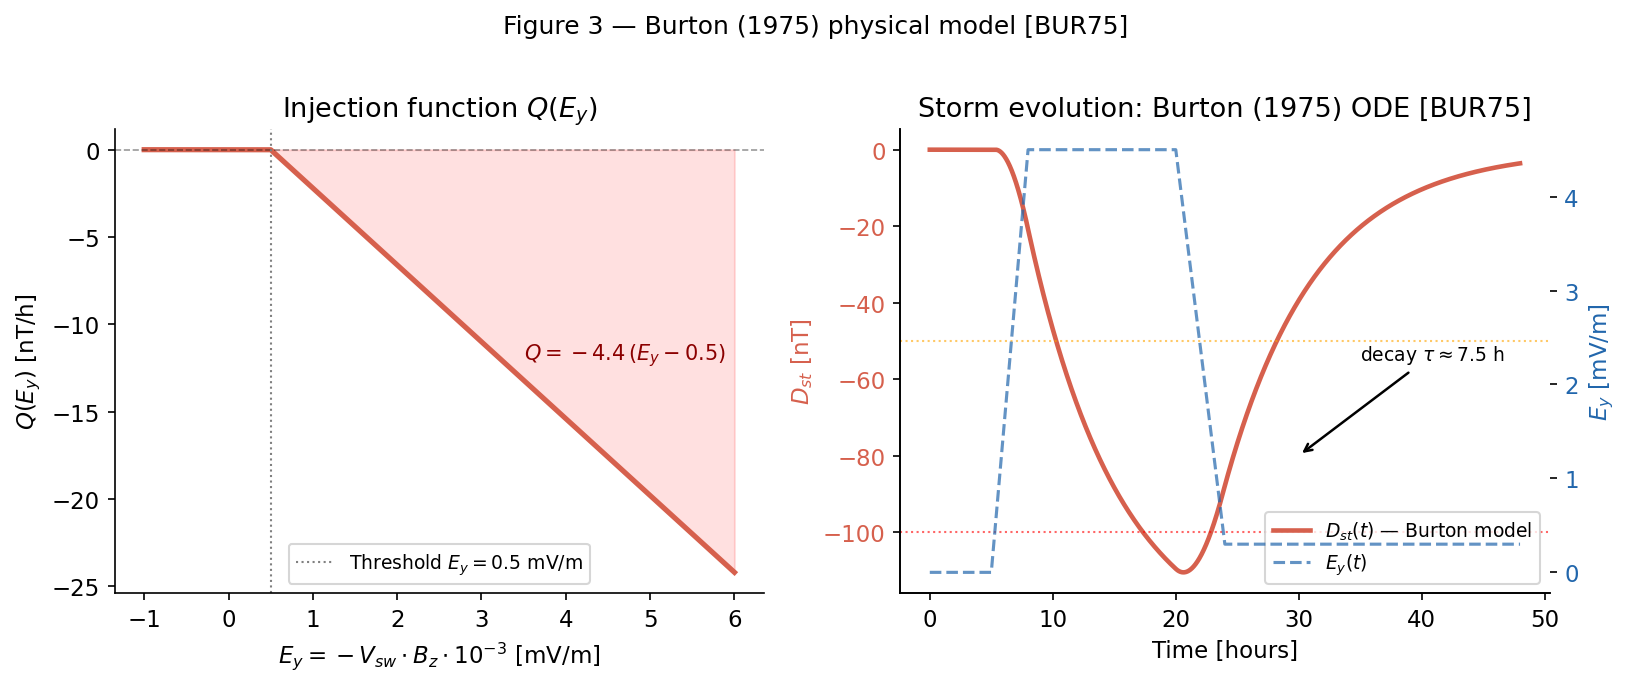

In [5]:
# ── Figure 3: Burton (1975) model ─────────────────────────────────────────────
Ey = np.linspace(-1, 6, 500)
Q  = np.where(Ey > 0.5, -4.4 * (Ey - 0.5), 0.0)

t2  = np.linspace(0, 48, 4800)
dt  = t2[1] - t2[0]
tau = 7.5
Ey_t = np.zeros(len(t2))
Ey_t[(t2 >= 5)  & (t2 < 8)]  = np.linspace(0, 4.5, ((t2 >= 5)  & (t2 < 8)).sum())
Ey_t[(t2 >= 8)  & (t2 < 20)] = 4.5
Ey_t[(t2 >= 20) & (t2 < 24)] = np.linspace(4.5, 0.3, ((t2 >= 20) & (t2 < 24)).sum())
Ey_t[t2 >= 24]  = 0.3
Q_t   = np.where(Ey_t > 0.5, -4.4 * (Ey_t - 0.5), 0.0)
Dst2  = np.zeros(len(t2))
for i in range(1, len(t2)):
    Dst2[i] = Dst2[i-1] + dt * (Q_t[i-1] - Dst2[i-1] / tau)

fig3, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(Ey, Q, color='#d6604d', lw=2.5)
axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
axes[0].axvline(0.5, color='gray', lw=1, ls=':', label='Threshold $E_y = 0.5$ mV/m')
axes[0].fill_between(Ey, Q, 0, where=(Q < 0), alpha=0.12, color='red')
axes[0].set_xlabel('$E_y = -V_{sw} \\cdot B_z \\cdot 10^{-3}$ [mV/m]')
axes[0].set_ylabel('$Q(E_y)$ [nT/h]')
axes[0].set_title('Injection function $Q(E_y)$')
axes[0].legend(fontsize=9)
axes[0].text(3.5, -12, '$Q = -4.4\\,(E_y - 0.5)$', fontsize=10, color='darkred')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

ax_r  = axes[1]
ax_r2 = ax_r.twinx()
ax_r2.plot(t2, Ey_t, color='#2166ac', lw=1.5, ls='--', alpha=0.7, label='$E_y(t)$')
ax_r2.set_ylabel('$E_y$ [mV/m]', color='#2166ac')
ax_r2.tick_params(axis='y', labelcolor='#2166ac')
ax_r2.spines['top'].set_visible(False)
ax_r.plot(t2, Dst2, color='#d6604d', lw=2.2, label='$D_{st}(t)$ — Burton model')
ax_r.axhline(-50,  color='orange', lw=1, ls=':', alpha=0.6)
ax_r.axhline(-100, color='red',    lw=1, ls=':', alpha=0.6)
ax_r.set_xlabel('Time [hours]')
ax_r.set_ylabel('$D_{st}$ [nT]', color='#d6604d')
ax_r.set_title('Storm evolution: Burton (1975) ODE [BUR75]')
ax_r.tick_params(axis='y', labelcolor='#d6604d')
ax_r.annotate('decay $\\tau \\approx 7.5$ h', xy=(30, -80), xytext=(35, -55),
              arrowprops=dict(arrowstyle='->', color='black', lw=1.2), fontsize=9)
lines1, labels1 = ax_r.get_legend_handles_labels()
lines2, labels2 = ax_r2.get_legend_handles_labels()
ax_r.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')
ax_r.spines['top'].set_visible(False)
ax.set_aspect('equal')
plt.suptitle('Figure 3 — Burton (1975) physical model [BUR75]', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/fig3_burton.png', dpi=150, bbox_inches='tight')
plt.show()

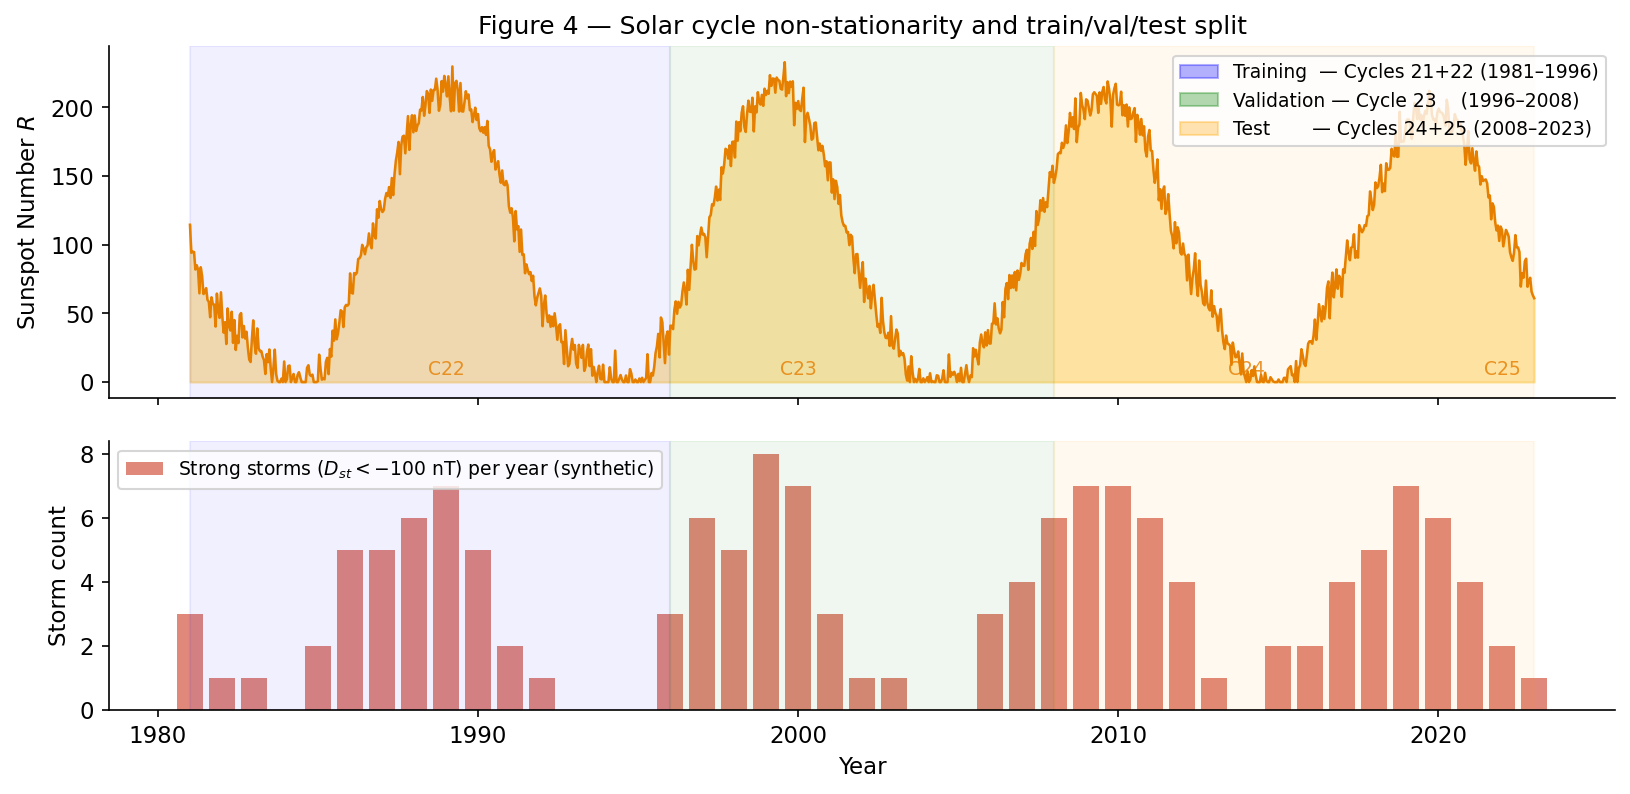

In [6]:
# ── Figure 4: Solar cycle and storm frequency ──────────────────────────────────
np.random.seed(7)
years = np.linspace(1981, 2023, 1000)

def solar_cycle(t):
    result = np.zeros_like(t)
    for tmin, period in [(1986, 10.0), (1996, 10.2), (2008, 9.9), (2019, 11.0)]:
        result += np.clip(np.sin(2 * np.pi * (t - tmin) / period) * 160 + 80, 0, None)
    return result / 4

ssn = solar_cycle(years) + np.random.normal(0, 8, len(years))
ssn = np.clip(ssn, 0, None)
year_bins   = np.arange(1981, 2024)
ssn_annual  = np.array([solar_cycle(np.array([y + 0.5]))[0] for y in year_bins])
storm_counts = np.clip(np.round(ssn_annual / 30 + np.random.normal(0, 0.8, len(year_bins))).astype(int), 0, None)

fig4, (ax_ssn, ax_st) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax_ssn.fill_between(years, ssn, alpha=0.35, color='#FDB813')
ax_ssn.plot(years, ssn, color='#e67e00', lw=1.2)
ax_ssn.set_ylabel('Sunspot Number $R$')
ax_ssn.set_title('Figure 4 — Solar cycle non-stationarity and train/val/test split', fontsize=12)
for yr, lbl in [(1989,'C22'), (2000,'C23'), (2014,'C24'), (2022,'C25')]:
    ax_ssn.text(yr, 5, lbl, ha='center', fontsize=9, color='#e67e00', alpha=0.8)

ax_st.bar(year_bins, storm_counts, color='#d6604d', alpha=0.75, width=0.8,
          label='Strong storms ($D_{st} < -100$ nT) per year (synthetic)')
ax_st.set_ylabel('Storm count')
ax_st.set_xlabel('Year')
ax_st.legend(fontsize=9)

handles = [
    mpatches.Patch(color='blue',   alpha=0.3, label='Training  — Cycles 21+22 (1981–1996)'),
    mpatches.Patch(color='green',  alpha=0.3, label='Validation — Cycle 23    (1996–2008)'),
    mpatches.Patch(color='orange', alpha=0.3, label='Test       — Cycles 24+25 (2008–2023)'),
]
for ax in [ax_ssn, ax_st]:
    ax.axvspan(1981, 1996, alpha=0.06, color='blue')
    ax.axvspan(1996, 2008, alpha=0.06, color='green')
    ax.axvspan(2008, 2023, alpha=0.06, color='orange')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax_ssn.legend(handles=handles, fontsize=9, loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('images/fig4_syntetic_solar_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

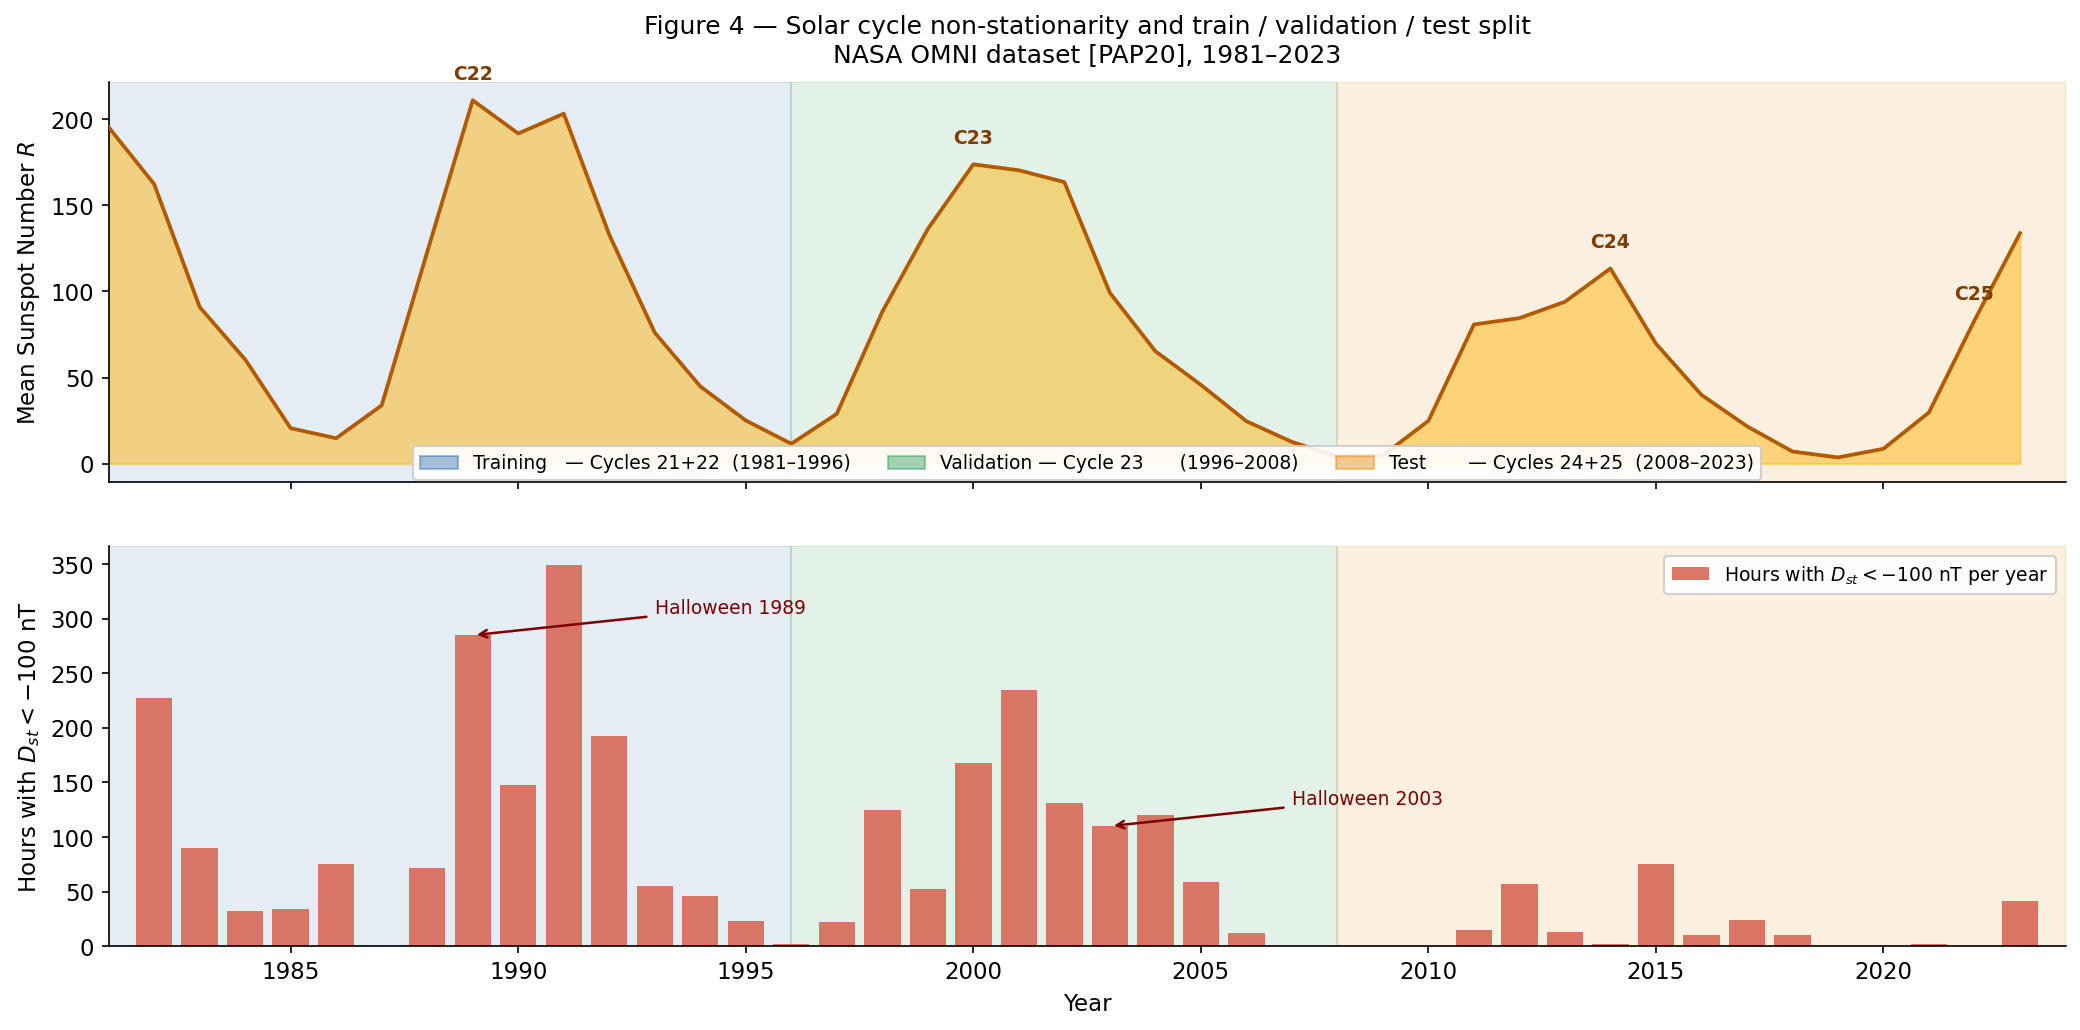

In [7]:
# ── Figure 4: Solar cycle non-stationarity and train/val/test split ───────────
# Real data from NASA OMNI dataset [PAP20], 1981–2023.
# Column indices follow the OMNI format file [KIN05]:
#   col 0  = YEAR
#   col 41 = R (Sunspot Number)
#   col 42 = Dst index [nT]

col_names = [str(i) for i in range(57)]
df = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)

df['year'] = df['0'].astype(int)
df['R']    = pd.to_numeric(df['41'], errors='coerce')
df['Dst']  = pd.to_numeric(df['42'], errors='coerce')

# Fill values → NaN (OMNI convention [KIN05])
df.loc[df['R']   == 999,   'R']   = np.nan
df.loc[df['Dst'] == 99999, 'Dst'] = np.nan

annual = df.groupby('year').agg(
    R_mean     = ('R',   'mean'),
    storms_str = ('Dst', lambda x: (x < -100).sum()),
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.patch.set_facecolor('white')

for ax in [ax1, ax2]:
    ax.axvspan(1981, 1996, alpha=0.12, color='#2166ac', zorder=0)
    ax.axvspan(1996, 2008, alpha=0.12, color='#1a9850', zorder=0)
    ax.axvspan(2008, 2024, alpha=0.12, color='#e67e00', zorder=0)
    ax.set_xlim(1981, 2024)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.fill_between(annual['year'], annual['R_mean'], alpha=0.5, color='#FDB813', zorder=2)
ax1.plot(annual['year'], annual['R_mean'], color='#b35900', lw=1.8, zorder=3)
ax1.set_ylabel('Mean Sunspot Number $R$')
ax1.set_title(
    'Figure 4 — Solar cycle non-stationarity and train / validation / test split\n'
    'NASA OMNI dataset [PAP20], 1981–2023',
    fontsize=12, pad=10
)

for yr, lbl in [(1989, 'C22'), (2000, 'C23'), (2014, 'C24'), (2022, 'C25')]:
    idx  = (annual['year'] - yr).abs().idxmin()
    yval = annual.loc[idx, 'R_mean']
    ax1.text(yr, yval + 12, lbl, ha='center', fontsize=9,
             color='#7f3b00', fontweight='bold', zorder=4)

handles_split = [
    mpatches.Patch(color='#2166ac', alpha=0.4, label='Training   — Cycles 21+22  (1981–1996)'),
    mpatches.Patch(color='#1a9850', alpha=0.4, label='Validation — Cycle 23      (1996–2008)'),
    mpatches.Patch(color='#e67e00', alpha=0.4, label='Test       — Cycles 24+25  (2008–2023)'),
]
ax1.legend(handles=handles_split, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, framealpha=0.9)

ax2.bar(annual['year'], annual['storms_str'],
        color='#d6604d', alpha=0.85, width=0.8, zorder=2,
        label='Hours with $D_{st} < -100$ nT per year')
ax2.set_ylabel('Hours with $D_{st} < -100$ nT')
ax2.set_xlabel('Year')

for yr, lbl, xoff, yoff in [(1989, 'Halloween 1989', 4, 20), (2003, 'Halloween 2003', 4, 20)]:
    idx  = annual[annual['year'] == yr].index[0]
    yval = annual.loc[idx, 'storms_str']
    ax2.annotate(lbl, xy=(yr, yval), xytext=(yr + xoff, yval + yoff),
                 arrowprops=dict(arrowstyle='->', color='#7f0000', lw=1.2),
                 fontsize=9, color='#7f0000', ha='left')

ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)

plt.tight_layout(h_pad=2.5)
plt.savefig('images/fig4_solar_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

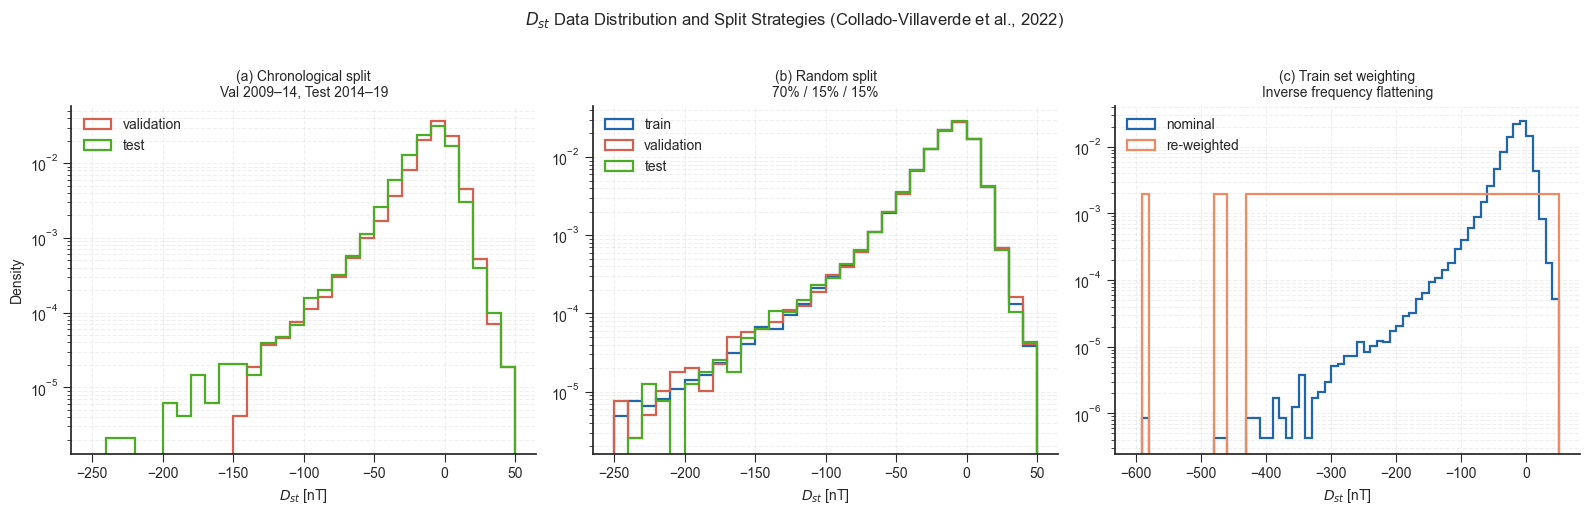

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Data Preparation ---
# Filter once to reduce memory overhead during splitting

# Parse column names from fmt file
col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()

# Load data
df_omni = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
df_omni['datetime'] = pd.to_datetime(
    df_omni['YEAR'].astype(str) + ' ' +
    df_omni['DOY'].astype(str) + ' ' +
    df_omni['Hour'].astype(str), format='%Y %j %H'
)

# --- Data Preparation ---
# Filter once to reduce memory overhead during splitting
mask_period = (df_omni['YEAR'] >= 1990) & (df_omni['YEAR'] < 2020)
dst_subset = df_omni.loc[mask_period, ['datetime', 'Dst-index, nT', 'YEAR']].dropna()
dst_vals = dst_subset['Dst-index, nT'].values

# --- Split Strategy (a): Chronological ---
train_mask = dst_subset['YEAR'] < 2009
val_mask = (dst_subset['YEAR'] >= 2009) & (dst_subset['datetime'] < '2014-07-01')
test_mask = dst_subset['datetime'] >= '2014-07-01'

splits_a = {
    'validation': dst_vals[val_mask],
    'test': dst_vals[test_mask]
}

# --- Split Strategy (b): Random ---
rng = np.random.default_rng(42)
indices = rng.permutation(len(dst_vals))
itrain, ival, itest = np.split(indices, [int(0.7*len(dst_vals)), int(0.85*len(dst_vals))])

splits_b = {
    'train': dst_vals[itrain],
    'validation': dst_vals[ival],
    'test': dst_vals[itest]
}

# --- Weighting Logic (c): Inverse Frequency ---
train_full = df_omni[df_omni['datetime'] < '2009-01-01']['Dst-index, nT']
bins_c = np.arange(-600, 60, 10)

# Vectorized frequency weighting
counts, edges = np.histogram(train_full, bins=bins_c)
bin_indices = np.clip(np.digitize(train_full, edges) - 1, 0, len(counts) - 1)
# Add epsilon to avoid division by zero if bins are empty
weights = 1.0 / np.maximum(counts[bin_indices], 1)
weights /= weights.mean() # Normalize to keep effective sample size consistent

# --- Optimized Plotting ---
plt.style.use('seaborn-v0_8-ticks') # Modern aesthetic
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
colors = {'train': '#2166ac', 'validation': '#d6604d', 'test': '#4dac26', 'weighted': '#ef8a62'}

def apply_styling(ax, title):
    ax.set_yscale('log')
    ax.set_xlabel('$D_{st}$ [nT]')
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)

# Panel (a)
for label, data in splits_a.items():
    axes[0].hist(data, bins=np.arange(-250, 60, 10), density=True, 
                 histtype='step', label=label, color=colors[label], lw=1.6)
apply_styling(axes[0], '(a) Chronological split\nVal 2009–14, Test 2014–19')
axes[0].set_ylabel('Density')

# Panel (b)
for label, data in splits_b.items():
    axes[1].hist(data, bins=np.arange(-250, 60, 10), density=True, 
                 histtype='step', label=label, color=colors[label], lw=1.6)
apply_styling(axes[1], '(b) Random split\n70% / 15% / 15%')

# Panel (c)
axes[2].hist(train_full, bins=bins_c, density=True, histtype='step', 
             label='nominal', color=colors['train'], lw=1.6)
axes[2].hist(train_full, bins=bins_c, weights=weights, density=True, 
             histtype='step', label='re-weighted', color=colors['weighted'], lw=1.6)
apply_styling(axes[2], '(c) Train set weighting\nInverse frequency flattening')

for ax in axes: ax.legend(frameon=False)
plt.suptitle('$D_{st}$ Data Distribution and Split Strategies (Collado-Villaverde et al., 2022)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('images/fig_dst_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()